### Wprowadzenie: Python, Google Colab oraz Keras z TensorFlow

Podczas dzisiejszych ćwiczeń będziemy korzystać z języka **Python** oraz nowoczesnych narzędzi wspierających budowę i trenowanie **sztucznych sieci neuronowych**.

Zajęcia są częścią kursu **Sztuczne Sieci Neuronowe (SSN)**. Ćwiczenia laboratoryjne składają się z **5 laboratoriów**, z których każde trwa **2 godziny i 15 minut**.  
Do zaliczenia kursu wymagana jest **obecność na co najmniej 3 laboratoriach**. Na zakończenie zajęć odbędzie się **kolokwium zaliczeniowe**.

Pracę będziemy wykonywać w środowisku **Google Colab** — czyli internetowym notatniku umożliwiającym uruchamianie kodu bez konieczności instalowania dodatkowego oprogramowania na własnym komputerze. Colab zapewnia dostęp do zasobów obliczeniowych (w tym **GPU**), co jest szczególnie przydatne w zadaniach związanych z uczeniem maszynowym.

Do budowy modeli wykorzystamy bibliotekę **Keras**, która działa jako wysokopoziomowy interfejs dla **TensorFlow**. Dzięki temu możliwe jest:

- szybkie definiowanie architektury sieci neuronowych,
- przejrzyste trenowanie modeli,
- łatwa analiza wyników.

**TensorFlow** odpowiada za wykonywanie obliczeń numerycznych oraz automatyczne różniczkowanie, natomiast **Keras** upraszcza proces projektowania modeli.

Celem ćwiczeń będzie praktyczne zapoznanie się z mechanizmami działania sieci neuronowych — od **definicji modelu**, przez **proces uczenia**, aż po **ocenę jego skuteczności**.

W razie potrzeby dodatkowe biblioteki można zainstalować poleceniem:

```python
!pip install <package-name>

```

(w Colabie używane tylko wtedy, gdy potrzebny pakiet nie jest już dostępny w środowisku. TF akurat jest).

In [1]:
import tensorflow as tf

### Tensor

Tensor to uogólnienie skalara, wektora i macierzy do dowolnej liczby wymiarów.

Formalnie:
- skalar → tensor rzędu 0  
- wektor → tensor rzędu 1  
- macierz → tensor rzędu 2  
- struktury o większej liczbie osi → tensory rzędu 3+

Tensor można więc traktować jako wielowymiarową tablicę liczb, na której można wykonywać operacje algebraiczne i numeryczne w sposób zoptymalizowany obliczeniowo (np. na GPU).

---

Poniższa komórka definiuje trzy tensory.  
Dodaj kod, który wywołuje na tych tensorach następujące operacje:

- kwadrat  
- pierwiastek  
- suma wszystkich możliwych i poprawnych par  
- różnica wszystkich możliwych i poprawnych par  
- iloczyn wszystkich możliwych i poprawnych par  
- transpozycja tensora

In [2]:
a = tf.ones((2, 2))
b = tf.constant([[1, 2, 3], [4, 5, 6]], dtype=tf.float32)
c = tf.constant([[1, 2], [2, 1]], dtype=tf.float32)

In [3]:
# Operacje element po elemencie - tylko gdy kształty się zgadzają

# Kwadrat każdego z tensorów (działa zawsze)
print("a^2 =\n", tf.square(a).numpy())
print("b^2 =\n", tf.square(b).numpy())
print("c^2 =\n", tf.square(c).numpy())

# Pierwiastek (a, b, c mają wartości >= 0)
print("\nsqrt(a) =\n", tf.sqrt(a).numpy())
print("sqrt(b) =\n", tf.sqrt(b).numpy())
print("sqrt(c) =\n", tf.sqrt(c).numpy())

# Suma, różnica, iloczyn elementowy - wymagają zgodnych kształtów.
# Pary o tym samym kształcie: (a, c)
print("\na + c =\n", (a + c).numpy())
print("a - c =\n", (a - c).numpy())
print("a * c (elementwise) =\n", (a * c).numpy())

# Iloczyn macierzowy - wymaga zgodności (n, k) @ (k, m).
# Pary poprawne dla matmul:
#   a @ b  -> (2,2) @ (2,3) = (2,3)
#   c @ b  -> (2,2) @ (2,3) = (2,3)
#   a @ c  -> (2,2) @ (2,2) = (2,2)
print("\na @ b =\n", tf.matmul(a, b).numpy())
print("c @ b =\n", tf.matmul(c, b).numpy())
print("a @ c =\n", tf.matmul(a, c).numpy())

# Transpozycja
print("\na.T =\n", tf.transpose(a).numpy())
print("b.T =\n", tf.transpose(b).numpy())
print("c.T =\n", tf.transpose(c).numpy())


a^2 =
 [[1. 1.]
 [1. 1.]]
b^2 =
 [[ 1.  4.  9.]
 [16. 25. 36.]]
c^2 =
 [[1. 4.]
 [4. 1.]]

sqrt(a) =
 [[1. 1.]
 [1. 1.]]
sqrt(b) =
 [[1.        1.4142135 1.7320508]
 [2.        2.236068  2.4494898]]
sqrt(c) =
 [[1.        1.4142135]
 [1.4142135 1.       ]]

a + c =
 [[2. 3.]
 [3. 2.]]
a - c =
 [[ 0. -1.]
 [-1.  0.]]
a * c (elementwise) =
 [[1. 2.]
 [2. 1.]]

a @ b =
 [[5. 7. 9.]
 [5. 7. 9.]]
c @ b =
 [[ 9. 12. 15.]
 [ 6.  9. 12.]]
a @ c =
 [[3. 3.]
 [3. 3.]]

a.T =
 [[1. 1.]
 [1. 1.]]
b.T =
 [[1. 4.]
 [2. 5.]
 [3. 6.]]
c.T =
 [[1. 2.]
 [2. 1.]]


### `tf.GradientTape` w TensorFlow

`tf.GradientTape` jest mechanizmem automatycznego różniczkowania w TensorFlow, umożliwiającym śledzenie operacji wykonywanych na tensorach oraz obliczanie gradientów funkcji względem wybranych zmiennych.

Stanowi on podstawowe narzędzie wykorzystywane podczas procesu uczenia sieci neuronowych, gdzie optymalizacja modelu opiera się na gradientach funkcji straty.

**Zalety:**

- automatyczne obliczanie pochodnych,
- działanie jako menedżer kontekstu (śledzenie operacji w bloku `with`),
- możliwość obliczania pochodnych wyższych rzędów (z użyciem trwałej taśmy, parametr `persistent=True`).

Przykład dla obliczenia prostej pochodnej funkcji nieliniowej

## Obliczanie pochodnej z użyciem `GradientTape`

Poniższy przykład pokazuje, jak w TensorFlow automatycznie obliczyć pochodną funkcji:

$$
y = x^2 + 2x + 3
$$


In [4]:
# Definiujemy punkt, w którym będziemy analizować funkcję
x = 2.0

# Definicja funkcji matematycznej
# f(x) = x^2 + 2x + 3
def f(x):
    return x**2 + 2*x + 3

# Obliczamy wartość funkcji w punkcie x
y = f(x)

# Wyświetlenie wyniku
print("x =", x)
print("f(x) =", y)

x = 2.0
f(x) = 11.0


Najpierw obliczymy pochodna analitycznie

In [5]:
# Pochodna funkcji
# f(x) = x^2 + 2x + 3

# Liczymy ją "ręcznie" z zasad rachunku różniczkowego:
# d/dx(x^2) = 2x
# d/dx(2x) = 2
# d/dx(3) = 0

# więc:
# f'(x) = 2x + 2

def df(x):
    return 2*x + 2

# Obliczamy pochodną w punkcie x = 2
print("Pochodna analityczna f'(x) =", df(x))

Pochodna analityczna f'(x) = 6.0


To samo policzymy z użyciem Tensorflow

In [6]:
# TensorFlow wymaga zmiennej typu tf.Variable,
# aby móc śledzić operacje wykonywane na tej zmiennej
x = tf.Variable(2.0)

# GradientTape zapisuje wszystkie operacje wykonywane
# na zmiennych wewnątrz bloku "with"
with tf.GradientTape() as tape:
    
    # Definicja tej samej funkcji co wcześniej
    y = x**2 + 2*x + 3

# TensorFlow oblicza pochodną dy/dx
dy_dx = tape.gradient(y, x)

print("Pochodna policzona przez TensorFlow:", dy_dx.numpy())

Pochodna policzona przez TensorFlow: 6.0


Poniższa komórka przedstawia przykład obliczenia gradientu funkcji kosztu dla sparametryzowanej funkcji f(x) (błąd średniokwadratowy - MSE)

In [7]:
# Dane wejściowe
x = tf.constant([1.0, 2.0, 3.0])

# Prawdziwe wartości
y_true = tf.constant([6.0, 11.0, 18.0])

# Parametry funkcji (będziemy je optymalizować)
w = tf.Variable(1.0)
b = tf.Variable(1.0)

# współczynnik uczenia
learning_rate = 0.01

# Funkcja modelu
# f(x) = w*x^2 + 2x + b
def f(x):
    return w * x**2 + 2*x + b

# ===== krok 1: predykcja i obliczenie błędu =====
with tf.GradientTape() as tape:

    y_pred = f(x)

    # błąd średniokwadratowy
    loss = tf.reduce_mean((y_pred - y_true)**2)

# ===== krok 2: obliczenie gradientów =====
grad_w, grad_b = tape.gradient(loss, [w, b])

print("Przed aktualizacją")
print("w =", w.numpy(), " b =", b.numpy())
print("MSE =", loss.numpy())


# Przykladowa aktualizacja wagi i biasu po obliczeniu gradientu
# ===== krok 3: aktualizacja parametrów (gradient descent) =====
# w.assign_sub(learning_rate * grad_w)
# b.assign_sub(learning_rate * grad_b)

# # ===== krok 4: sprawdzenie nowego błędu =====
# y_pred_new = f(x)
# loss_new = tf.reduce_mean((y_pred_new - y_true)**2)

# print("\nPo jednym kroku optymalizacji")
# print("w =", w.numpy(), " b =", b.numpy())
# print("Nowy MSE =", loss_new.numpy())

Przed aktualizacją
w = 1.0  b = 1.0
MSE = 4.0


**ZADANIE**

Obliczyć gradient dla funkcji:

$$
y = x^2 + 16x + 4566769
$$

$$
y = x^3 + x^2 + x
$$

w punktach x = [3, 2, 7, 1]

In [8]:
# Obliczenie gradientu w wielu punktach jednocześnie za pomocą tf.GradientTape

xs = tf.constant([3.0, 2.0, 7.0, 1.0])

# --- Funkcja 1: y = x^2 + 16x + 4566769, dy/dx = 2x + 16 ---
with tf.GradientTape() as tape1:
    tape1.watch(xs)
    y1 = xs**2 + 16*xs + 4566769

grad1 = tape1.gradient(y1, xs)
print("f1(x) = x^2 + 16x + 4566769")
print("  punkty:    ", xs.numpy())
print("  pochodna:  ", grad1.numpy(), " (analitycznie: 2x+16)")

# --- Funkcja 2: y = x^3 + x^2 + x, dy/dx = 3x^2 + 2x + 1 ---
with tf.GradientTape() as tape2:
    tape2.watch(xs)
    y2 = xs**3 + xs**2 + xs

grad2 = tape2.gradient(y2, xs)
print("\nf2(x) = x^3 + x^2 + x")
print("  punkty:    ", xs.numpy())
print("  pochodna:  ", grad2.numpy(), " (analitycznie: 3x^2+2x+1)")


f1(x) = x^2 + 16x + 4566769
  punkty:     [3. 2. 7. 1.]
  pochodna:   [22. 20. 30. 18.]  (analitycznie: 2x+16)

f2(x) = x^3 + x^2 + x
  punkty:     [3. 2. 7. 1.]
  pochodna:   [ 34.  17. 162.   6.]  (analitycznie: 3x^2+2x+1)


---
## Przykład: dopasowanie funkcji liniowej

W tym przykładzie zobaczymy najprostszy możliwy model uczący się na danych — **model liniowy**.  
Choć jest bardzo prosty, stanowi on podstawę działania pojedynczego neuronu w sieci neuronowej.

Model liniowy opisuje zależność pomiędzy zmienną wejściową a wyjściową za pomocą równania:

$$
y = w \cdot x + b
$$

gdzie:

- **$x$** — dane wejściowe (input),
- **$w$** — waga modelu (*weight*),
- **$b$** — bias, czyli przesunięcie,
- **$y$** — przewidywana wartość wyjściowa modelu.

W trakcie uczenia model próbuje znaleźć takie wartości parametrów **$w$** oraz **$b$**, które najlepiej dopasują funkcję do danych treningowych.

Proces uczenia modelu można opisać w kilku krokach:

1. model generuje przewidywania  
   $$
   y_{pred} = w \cdot x + b
   $$

2. obliczana jest **funkcja straty** (błąd pomiędzy predykcją a wartością referencyjną)

3. wyznaczane są **gradienty funkcji straty** względem parametrów modelu

4. parametry **$w$** i **$b$** są aktualizowane w kierunku zmniejszającym błąd

W kolejnych komórkach zobaczymy, jak zbudować taki model w **TensorFlow**, a następnie jak nauczyć go dopasowywać się do danych.

### Definicja modelu

Model funkcji liniowej opisany jest równaniem:

$$
y = w \cdot x + b
$$

gdzie:

- **$w$**, **$b$** — parametry modelu (wagi),
- **$x$** — wejście modelu,
- **$y$** — wyjście modelu (predykcja).

In [9]:
# Zdefiniowanie modelu jako klasy
class LinearModel:

    def __init__(self, w_init, b_init):
        """
        Inicjalizacja parametrów modelu.

        w_init – początkowa wartość wagi
        b_init – początkowa wartość biasu

        W praktyce parametry modelu zwykle inicjalizuje się losowo,
        np. za pomocą tf.random.normal().
        """
        self.w = tf.Variable(w_init, dtype=tf.float32)
        self.b = tf.Variable(b_init, dtype=tf.float32)

    def __call__(self, x):
        """
        Forward pass modelu.

        x – dane wejściowe

        Zwraca:
        y_pred – przewidywanie modelu
        """
        y_pred = self.w * x + self.b
        return y_pred

In [10]:
lin_model = LinearModel(5.0, 0.0)

In [11]:
lin_model(3.0)

<tf.Tensor: shape=(), dtype=float32, numpy=15.0>

In [12]:
# wyznaczenie wektora wyjść
lin_model([1.0, 3.0, 5.0]).numpy()

array([ 5., 15., 25.], dtype=float32)

### Definicja funkcji straty

Aby model mógł się uczyć, potrzebujemy **funkcji straty** (*loss function*), która mierzy błąd pomiędzy wartością przewidywaną przez model a wartością rzeczywistą.

W tym przykładzie wykorzystamy **błąd średniokwadratowy (Mean Squared Error – MSE)**.

$$
L = \frac{1}{n} \sum_{i=1}^{n} (y_{\text{pred}} - y_{\text{true}})^2
$$

gdzie:

- $y_{\text{pred}}$ — wartość przewidywana przez model,
- $y_{\text{true}}$ — wartość referencyjna (rzeczywista),
- $n$ — liczba obserwacji.

Funkcja straty informuje nas **jak bardzo model się myli** podczas predykcji.  
Podczas uczenia będziemy minimalizować jej wartość poprzez aktualizację parametrów modelu ($w$ oraz $b$).

Funkcję straty można zdefiniować jako osobną funkcję lub dodać ją bezpośrednio do klasy modelu.

In [13]:
def lossMSE(predicted_y, target_y):
    return tf.reduce_mean(tf.pow(predicted_y - target_y, 2))

### Pozyskiwanie danych treningowych

Aby nauczyć model, potrzebujemy **danych treningowych**.  
W tym przykładzie wygenerujemy dane syntetyczne na podstawie znanej funkcji liniowej.

Zakładamy, że rzeczywista zależność pomiędzy zmienną wejściową a wyjściową ma postać:

$$
y = w_{true} \cdot x + b_{true}
$$

gdzie:

- $x$ — dane wejściowe,
- $y$ — wartość referencyjna,
- $w_{true}$ — prawdziwa waga,
- $b_{true}$ — prawdziwy bias.

Najpierw generujemy losowe wartości wejściowe $x$. Następnie obliczamy odpowiadające im wartości $y$ zgodnie z powyższym równaniem.

Aby symulować bardziej realistyczne dane, dodamy również **szum losowy**. Dzięki temu model nie będzie dopasowywał się do idealnej prostej, lecz do danych zbliżonych do rzeczywistych obserwacji.

W efekcie otrzymamy:

- **$x$** — dane wejściowe,
- **$y_{true}$** — wartości referencyjne bez szumu,
- **$y_{noise}$** — wartości referencyjne z dodanym szumem.

Na tych danych będziemy trenować nasz model.

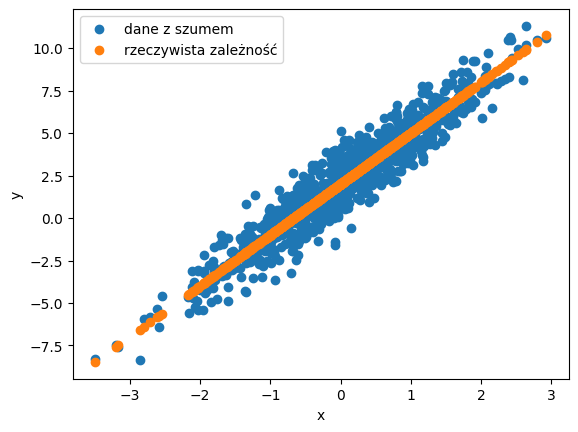

In [14]:
import matplotlib.pyplot as plt

w_true = 3.0
b_true = 2.0
n_samples = 1000

# losowe dane wejściowe
x = tf.random.normal(shape=[n_samples])

# szum losowy
noise = tf.random.normal(shape=[n_samples])

# wartości referencyjne
y_true = w_true * x + b_true

# wartości z dodanym szumem
y_noise = y_true + noise

# wizualizacja danych
plt.scatter(x, y_noise, label="dane z szumem")
plt.scatter(x, y_true, label="rzeczywista zależność")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Wyświetlenie wartości treningowych oraz wyjścia z nienauczonego modelu.

In [15]:
# Tworzymy model z losowymi (niedopasowanymi) parametrami
model = LinearModel(7.0, -2.0)

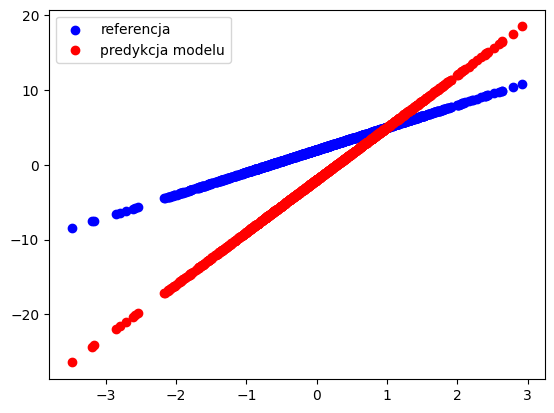

Wartość funkcji straty: 30.082415


In [16]:
# wykresy
plt.scatter(x, y_true, c='b')
plt.scatter(x, model(x), c='r')

plt.legend(["referencja", "predykcja modelu"])
plt.show()

# policzenie błędu
print("Wartość funkcji straty: %1.6f" % lossMSE(model(x), y_true).numpy())

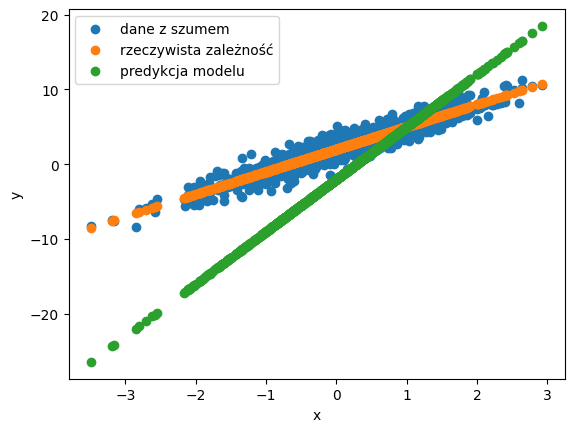

Wartość funkcji straty: 30.082415


In [17]:
# predykcja modelu
y_pred = model(x)

# wizualizacja danych
plt.scatter(x, y_noise, label="dane z szumem")
plt.scatter(x, y_true, label="rzeczywista zależność")
plt.scatter(x, y_pred, label="predykcja modelu")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# obliczenie błędu dla aktualnych parametrów modelu
print("Wartość funkcji straty: %1.6f" % lossMSE(y_pred, y_true).numpy())

### Funkcja ucząca model liniowy

Tworzymy funkcję odpowiedzialną za **trenowanie modelu**, czyli aktualizację jego parametrów na podstawie danych treningowych.

Wykorzystujemy mechanizm **`tf.GradientTape`**, który pozwala automatycznie obliczyć gradient funkcji straty względem parametrów modelu.

Proces uczenia w jednej iteracji przebiega następująco:

1. Model wykonuje **przejście w przód (forward pass)** i generuje predykcję:

$$
y_{pred} = w \cdot x + b
$$

2. Obliczana jest **funkcja straty**, która mierzy błąd pomiędzy predykcją a wartością rzeczywistą:

$$
L = \text{loss}(y_{pred}, y_{true})
$$

3. Za pomocą `GradientTape` wyznaczamy **gradient funkcji straty** względem parametrów modelu:

$$
\frac{\partial L}{\partial w}, \quad \frac{\partial L}{\partial b}
$$

4. Parametry modelu są aktualizowane w kierunku zmniejszającym błąd:

$$
w = w - \eta \frac{\partial L}{\partial w}
$$

$$
b = b - \eta \frac{\partial L}{\partial b}
$$

gdzie:

- $\eta$ — **learning rate**, czyli krok uczenia,
- $\frac{\partial L}{\partial w}$ i $\frac{\partial L}{\partial b}$ — gradienty funkcji straty.

Dzięki wielokrotnemu powtarzaniu tego procesu model stopniowo dopasowuje się do danych treningowych.

In [18]:
def train(model, x, y_true, learning_rate):
    # GradientTape zapisuje operacje wykonywane na tensorach
    with tf.GradientTape() as tape:

        # forward pass – predykcja modelu
        y_pred = model(x)

        # obliczenie funkcji straty
        loss = lossMSE(y_pred, y_true)

    # obliczenie gradientów funkcji straty względem parametrów modelu
    dw, db = tape.gradient(loss, [model.w, model.b])

    # aktualizacja parametrów (gradient descent)
    model.w.assign_sub(learning_rate * dw)
    model.b.assign_sub(learning_rate * db)

    # zwracamy wartość funkcji straty
    return loss

### Pętla treningowa

- wykonanie kilku epok, czyli treningów na zbiorze treningowym
- zbieranie skorygowanych wag
- wyświetlenie wykresu zmiany wag oraz błędu

Epoch  0: w=-20.00 b=30.00, loss=1233.44202
Epoch  1: w=-15.74 b=24.68, loss=813.11322
Epoch  2: w=-12.27 b=20.38, loss=536.15057
Epoch  3: w=-9.44 b=16.89, loss=353.64813
Epoch  4: w=-7.14 b=14.07, loss=233.38541
Epoch  5: w=-5.26 b=11.78, loss=154.13400
Epoch  6: w=-3.73 b=9.93, loss=101.90692
Epoch  7: w=-2.49 b=8.43, loss=67.48803
Epoch  8: w=-1.48 b=7.22, loss=44.80457
Epoch  9: w=-0.65 b=6.23, loss=29.85486
Epoch 10: w=0.02 b=5.43, loss=20.00191
Epoch 11: w=0.57 b=4.79, loss=13.50795
Epoch 12: w=1.01 b=4.26, loss=9.22777
Epoch 13: w=1.37 b=3.84, loss=6.40664
Epoch 14: w=1.67 b=3.50, loss=4.54716
Epoch 15: w=1.91 b=3.22, loss=3.32150
Epoch 16: w=2.10 b=2.99, loss=2.51362
Epoch 17: w=2.26 b=2.81, loss=1.98109
Epoch 18: w=2.39 b=2.66, loss=1.63006
Epoch 19: w=2.50 b=2.54, loss=1.39868
Epoch 20: w=2.58 b=2.44, loss=1.24615
Epoch 21: w=2.65 b=2.36, loss=1.14560
Epoch 22: w=2.71 b=2.30, loss=1.07932
Epoch 23: w=2.76 b=2.25, loss=1.03563
Epoch 24: w=2.79 b=2.20, loss=1.00683
Epoch 25: w

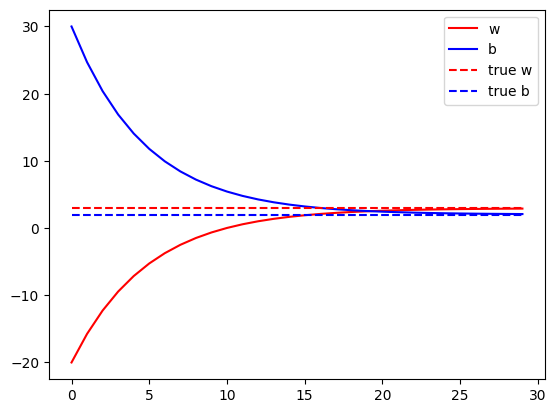

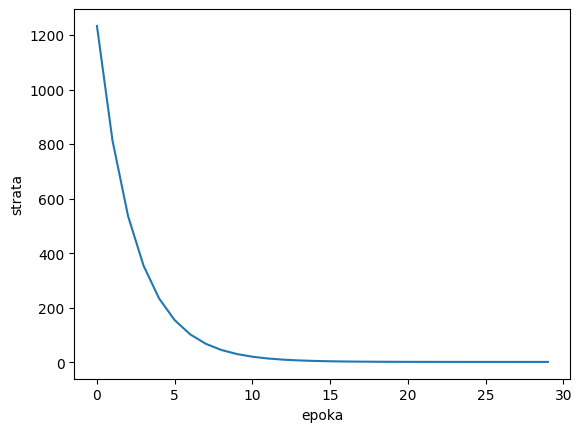

In [19]:
# nowy model z losowymi parametrami
model = LinearModel(-20.0, 30.0)

# kontenery na historię parametrów i błędu
w_history, b_history, loss_history = [], [], []

# liczba epok treningu
epochs = range(30)

# pętla treningowa
for epoch in epochs:

    # zapis aktualnych parametrów
    w_history.append(model.w.numpy())
    b_history.append(model.b.numpy())

    # jedna iteracja uczenia
    loss = train(model, x, y_noise, learning_rate=0.1)

    # zapis wartości funkcji straty
    loss_history.append(loss.numpy())

    print(
        "Epoch %2d: w=%1.2f b=%1.2f, loss=%2.5f"
        % (epoch, w_history[-1], b_history[-1], loss)
    )

# wizualizacja zmian parametrów w czasie
plt.plot(epochs, w_history, 'r', label="w")
plt.plot(epochs, b_history, 'b', label="b")

# prawdziwe wartości parametrów
plt.plot([w_true] * len(epochs), 'r--', label="true w")
plt.plot([b_true] * len(epochs), 'b--', label="true b")

plt.legend()
plt.show()

# wykres funkcji straty
plt.plot(epochs, loss_history)
plt.xlabel("epoka")
plt.ylabel("strata")
plt.show()

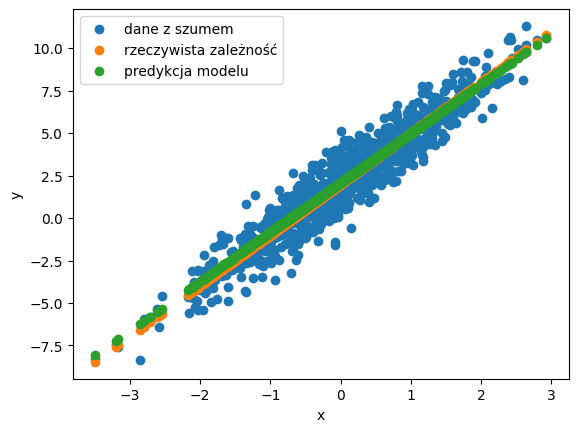

Dane bez szumu | wartość funkcji straty: 0.013045
Dane z szumem | wartość funkcji straty: 0.955683


In [20]:
# predykcja modelu
y_pred = model(x)

# wizualizacja danych i dopasowania modelu
plt.scatter(x, y_noise, label="dane z szumem")
plt.scatter(x, y_true, label="rzeczywista zależność")
plt.scatter(x, y_pred, label="predykcja modelu")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# obliczenie błędu dla aktualnych parametrów modelu
print("Dane bez szumu | wartość funkcji straty: %1.6f" % lossMSE(y_pred, y_true).numpy())
print("Dane z szumem | wartość funkcji straty: %1.6f" % lossMSE(y_pred, y_noise).numpy())

## Przewidywanie autentyczności banknotów z użyciem sieci neuronowych (Keras)

W tej części ćwiczeń rozważymy zadanie klasyfikacji z wykorzystaniem sztucznej sieci neuronowej.

Celem będzie przewidywanie autentyczności banknotów na podstawie cech numerycznych opisujących ich strukturę.

Wykorzystany zostanie zbiór danych:
https://archive.ics.uci.edu/dataset/267/banknote+authentication

**Do załadowania danych proszę pobrać plik csv z repozytorium github (folder Laboratoria 1).**

---

### Opis problemu

Zbiór danych pochodzi z repozytorium UCI Machine Learning i został utworzony na podstawie obrazów prawdziwych oraz fałszywych banknotów.

Obrazy zostały przetworzone z użyciem transformacji falkowej (Wavelet Transform), a następnie wyekstrahowano z nich cztery cechy statystyczne opisujące strukturę obrazu.

Zadanie ma charakter klasyfikacji binarnej — model ma określić, czy banknot jest:

- autentyczny  
- fałszywy  

---

### Struktura danych

Zbiór zawiera:

- 1372 obserwacje  
- 4 cechy wejściowe (numeryczne):
  - variance — wariancja obrazu po transformacji falkowej  
  - skewness — skośność  
  - curtosis — kurtoza  
  - entropy — entropia obrazu  

- 1 zmienną docelową:
  - class  
    - 0 — banknot autentyczny  
    - 1 — banknot fałszywy  

Zbiór nie zawiera braków danych.

---

### Cel ćwiczenia

Zbudujemy model sieci neuronowej w Keras, który nauczy się rozpoznawać wzorce charakterystyczne dla banknotów i dokona klasyfikacji: autentyczny vs fałszywy.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

Wczytaj zbiór danych

In [22]:
df = pd.read_csv('banknote.csv') #W zależności od miejsca zapisania pliku, ścieżka dostępu może wymagać zmiany.

Inwestygacja zbioru danych

In [23]:
df.head()


,0,1,2,3,target
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [24]:
df.dtypes


0         float64
1         float64
2         float64
3         float64
target      int64
dtype: object

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>],
       [<Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

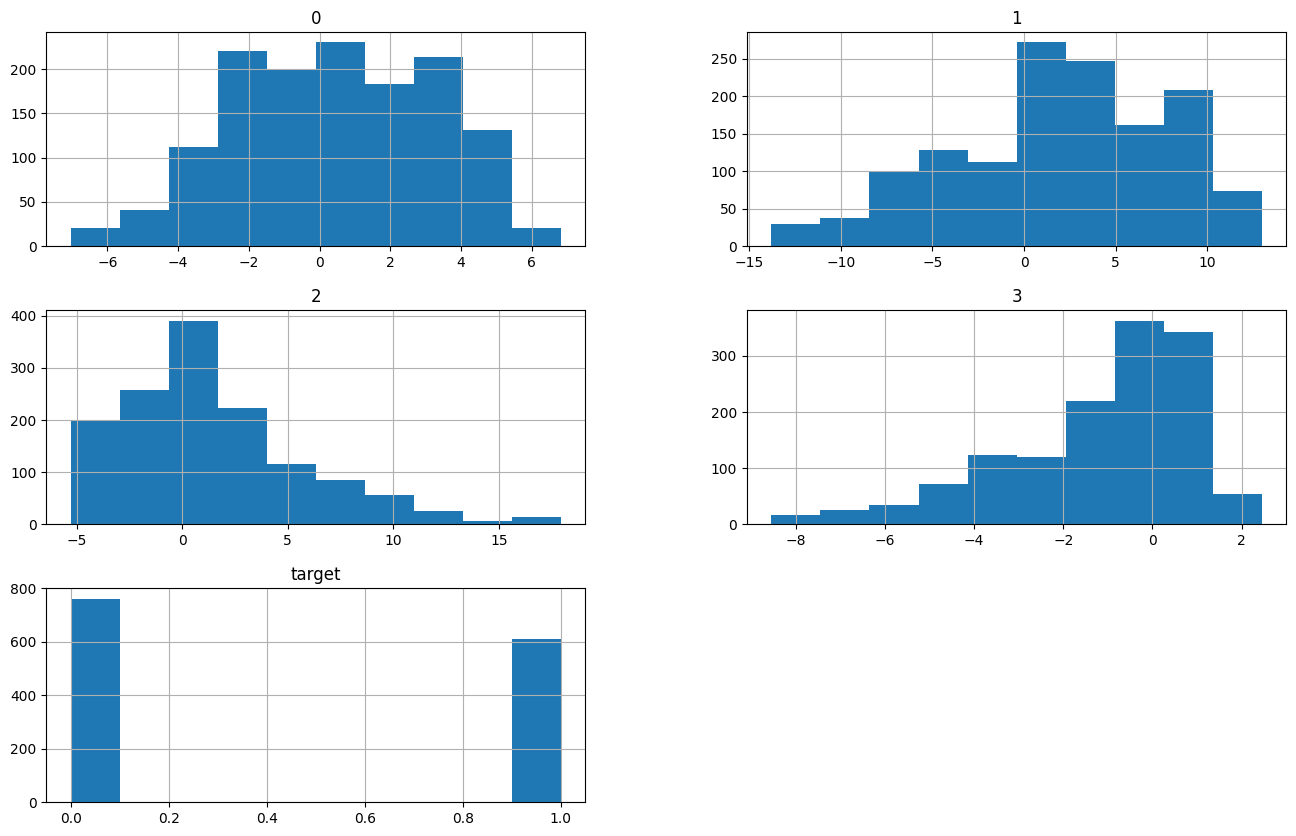

In [25]:
df.hist(bins=10, figsize=(16,10))

Wyznaczenie kolumny do nauki sieci - target

In [26]:
target_col = 'target'
target = df[target_col]


Wyznaczenie kolumn do nauki sieci - cechy

In [27]:
numeric_features = df.drop(target_col, axis=1)
num_features = numeric_features.shape[1]
numeric_features.head()


,0,1,2,3
0,3.62160,8.6661,-2.8073,-0.44699
1,4.54590,8.1674,-2.4586,-1.46210
2,3.86600,-2.6383,1.9242,0.10645
3,3.45660,9.5228,-4.0112,-3.59440
4,0.32924,-4.4552,4.5718,-0.98880


### Budowa sieci

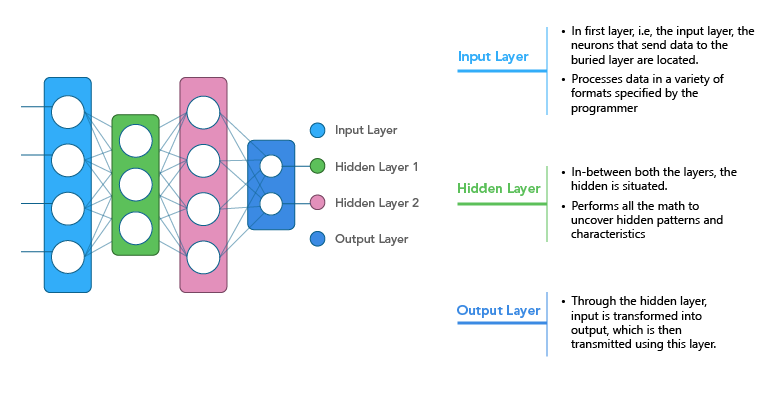

(źródło: https://www.softwebsolutions.com/resources/difference-between-cnn-rnn-ann.html)

### Podstawowy model sztucznej sieci neuronowej w Keras — `Sequential`

Model typu `Sequential` stanowi najprostszą architekturę sieci neuronowej w Keras, w której warstwy są ułożone liniowo — każda kolejna warstwa otrzymuje dane wyjściowe z warstwy poprzedniej.

In [28]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

In [29]:
model = Sequential([
    # Warstwa wejściowa + pierwsza warstwa ukryta
    # 12 neuronów, inicjalizacja wag rozkładem jednostajnym,
    # funkcja aktywacji ReLU wprowadzająca nieliniowość
    Dense(12, input_dim=num_features, kernel_initializer='uniform', activation='relu'),

    # Dropout – losowe wyzerowanie 20% neuronów podczas uczenia
    # w celu ograniczenia przeuczenia (regularizacja)
    Dropout(0.2),

    # Druga warstwa ukryta
    # 6 neuronów, ponownie ReLU jako funkcja aktywacji
    Dense(6, kernel_initializer='uniform', activation='relu'),

    # Dropout – losowe wyzerowanie 10% neuronów
    Dropout(0.1),

    # Warstwa wyjściowa
    # 1 neuron z funkcją sigmoidalną
    # generuje prawdopodobieństwo przynależności do klasy (klasyfikacja binarna)
    Dense(1, kernel_initializer='uniform', activation='sigmoid')
])

In [30]:
# Kompilacja modelu – określenie sposobu uczenia

model.compile(
    loss='binary_crossentropy',   # funkcja straty odpowiednia dla klasyfikacji binarnej
                                 # mierzy różnicę między przewidywanym prawdopodobieństwem
                                 # a rzeczywistą etykietą klasy

    optimizer="SGD",          # optymalizator odpowiedzialny za aktualizację wag
                                 # często stabilny przy rzadkich cechach i szumie

    metrics=['accuracy']         # metryka oceny modelu podczas treningu i walidacji
                                 # określa odsetek poprawnych klasyfikacji
)

# Wyświetlenie architektury modelu:
# liczba warstw, liczba parametrów oraz ich podział
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

Trening modelu

In [31]:
model.fit(
    numeric_features,   # dane wejściowe (cechy)
    target,             # zmienna docelowa (etykiety klas)

    epochs=10,          # liczba epok – ile razy model przejdzie przez cały zbiór treningowy

    batch_size=16,      # liczba obserwacji przetwarzanych jednocześnie
                        # przed aktualizacją wag (mini-batch learning)

    validation_split=0.33  # 33% danych zostaje automatycznie wydzielone
                           # jako zbiór walidacyjny do monitorowania uczenia
)

Epoch 1/10


 1/58 ━━━━━━━━━━━━━━━━━━━━ 27s 483ms/step - accuracy: 0.1250 - loss: 0.6935

48/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7574 - loss: 0.6812   

58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8161 - loss: 0.6654 - val_accuracy: 0.0000e+00 - val_loss: 0.7856


Epoch 2/10


...

 1/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8125 - loss: 0.5071

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8292 - loss: 0.4885 - val_accuracy: 0.0000e+00 - val_loss: 1.3037


Epoch 10/10


 1/58 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9375 - loss: 0.3780

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8292 - loss: 0.4824 - val_accuracy: 0.0000e+00 - val_loss: 1.3439


In [32]:
# Ewaluacja modelu

loss, accuracy = model.evaluate(
    numeric_features,  # dane wejściowe użyte do oceny
    target             # rzeczywiste etykiety
)

# model.evaluate zwraca:
# - wartość funkcji straty
# - wartość metryki (tu: accuracy)

print(f'Test Accuracy: {accuracy:.2f}')  # wyświetlenie dokładności modelu

 1/43 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.3017

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5554 - loss: 0.7651 


Test Accuracy: 0.56


Predykcje

In [33]:
# Predykcja dla pierwszych trzech obserwacji

model.predict(
    numeric_features.iloc[:3]   # wybór pierwszych 3 rekordów ze zbioru danych
)

# Wynikiem są przewidywane prawdopodobieństwa
# przynależności do klasy pozytywnej (wyjście warstwy sigmoid)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([[0.26000044],
       [0.25999358],
       [0.26109782]], dtype=float32)

Analiza treningu

In [34]:
# Wizualizacja architektury modelu

tf.keras.utils.plot_model(
    model,
    rankdir="LR",      # układ warstw od lewej do prawej (Left → Right)
    show_shapes=True   # wyświetlenie wymiarów tensorów pomiędzy warstwami
)

# Generuje graficzne przedstawienie struktury sieci neuronowej

You must install pydot (`pip install pydot`) for `plot_model` to work.


**Zadanie**

Wykonać analogiczne zadanie dla zbioru danych `BreastCancer`.

### Wymagania

- zastosować podział na dane treningowe i testowe,
- dodać metryki: **precision** i **recall** (lub inne odpowiednie w przypadku klasyfikacji wieloklasowej),

- (opcja) zamiast danych `BreastCancer` wykorzystać własny zbiór do klasyfikacji  
  (np. z UCI ML, PMLB, Kaggle lub dane syntetyczne),

- jeżeli dane zawierają więcej niż dwie klasy:
  - wykonać enkodowanie zmiennej docelowej,
  - dostosować warstwę wyjściową sieci (np. liczba neuronów, funkcja aktywacji),
  - wybrać odpowiednią funkcję kosztu (loss).

### Rozszerzenie

Spróbować zmodyfikować architekturę sieci i proces uczenia w celu poprawy wyników:

- strategia train–test split,
- architektura sieci,
- warstwa BatchNormalization,
- dobór optymalizatora i jego parametrów,
- warstwy Dropout,
- liczba epok.

In [35]:
!pip install scikit-learn

zsh:1: command not found: pip


In [36]:
from sklearn.datasets import load_breast_cancer

In [37]:
x, y = load_breast_cancer(return_X_y=True, as_frame=True)

Test - loss: 0.0727  acc: 0.9649  precision: 0.9857  recall: 0.9583

               precision    recall  f1-score   support

           0      0.932     0.976     0.953        42
           1      0.986     0.958     0.972        72

    accuracy                          0.965       114
   macro avg      0.959     0.967     0.963       114
weighted avg      0.966     0.965     0.965       114



Confusion matrix:
 [[41  1]
 [ 3 69]]


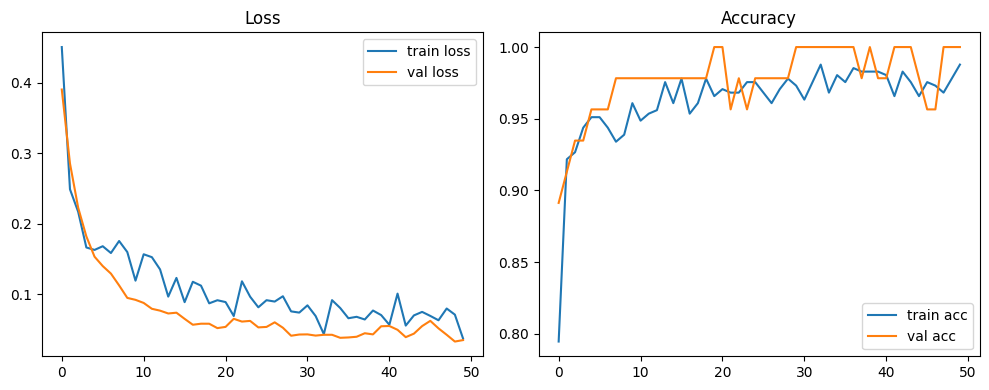

In [38]:
# Sieć neuronowa do klasyfikacji raka piersi (BreastCancer)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

# Podział train/test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Standaryzacja cech (zalecane dla NN)
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s  = scaler.transform(x_test)

# Architektura sieci - BN + Dropout dla lepszej generalizacji
bc_model = Sequential([
    Input(shape=(x_train_s.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),  # klasyfikacja binarna
])

bc_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

history = bc_model.fit(
    x_train_s, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=16,
    verbose=0,
)

# Ewaluacja na zbiorze testowym
loss, acc, prec_tf, rec_tf = bc_model.evaluate(x_test_s, y_test, verbose=0)
print(f"Test - loss: {loss:.4f}  acc: {acc:.4f}  precision: {prec_tf:.4f}  recall: {rec_tf:.4f}")

# Pełen raport klasyfikacyjny
y_pred_prob = bc_model.predict(x_test_s, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
print("\n", classification_report(y_test, y_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# Krzywe uczenia
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.title('Accuracy')
plt.tight_layout(); plt.show()
